In [ ]:
!pip install langchain-groq


In [ ]:
from google.colab import userdata
groq_api_key=userdata.get("GROQ_API_KEY")
from langchain_groq import ChatGroq
llm = ChatGroq(
    groq_api_key=groq_api_key,
    model="llama-3.3-70b-versatile",
    temperature=0.7,
)

In [ ]:
llm.invoke("I want to know the meaning of water ").content

"A simple yet profound question!\n\nWater is a chemical compound made up of two hydrogen atoms and one oxygen atom, with the chemical formula H2O. It's a clear, colorless, and odorless liquid that's essential for life on Earth.\n\nIn a broader sense, water can have many meanings and interpretations, depending on the context. Here are a few:\n\n1. **Scientific meaning**: Water is a substance that's composed of hydrogen and oxygen atoms, with a specific molecular structure and properties.\n2. **Biological meaning**: Water is essential for life, as it makes up a significant portion of all living organisms and plays a crucial role in many biological processes, such as metabolism, growth, and reproduction.\n3. **Environmental meaning**: Water is a vital component of the Earth's ecosystem, covering about 71% of the planet's surface and regulating the climate, weather patterns, and geological processes.\n4. **Cultural meaning**: Water has significant cultural, spiritual, and symbolic meanings

# Pydantic Schema

In [ ]:
from pydantic import BaseModel,Field

class  graph_schema(BaseModel):
  topic: str=Field(description="The topic of the graph")
  post:str= Field(description="The Linkedin post content")
  #curated post for updated information for LLM
  curated_post: str= Field(description="The Curated Linkedin post content")
#parse the object

demo_obj = graph_schema(
    topic="The importance of data privacy in the digital age",
    post="Data privacy is crucial in today's digital world. With the increasing amount of personal information being shared online, it's important to understand how to protect your data and maintain your privacy.",
    curated_post="In the digital age, data privacy is more important than ever. With the"
)
print(demo_obj)

#


topic='The importance of data privacy in the digital age' post="Data privacy is crucial in today's digital world. With the increasing amount of personal information being shared online, it's important to understand how to protect your data and maintain your privacy." curated_post='In the digital age, data privacy is more important than ever. With the'


# Create the Nodes

In [ ]:
def create_post(state:graph_schema)-> graph_schema:
  #convert pydantic model to dictionary
  state=state.model_dump()
  #Extract the topic from the state
  topic=state['topic']
  #passing the topic to the LLm to generetate a linkedin post
  post=llm.invoke(f"write a linkedin post about {topic}").content

  # update the state with the generated post
  state['post']=post

  return state

def curate_post(state:graph_schema)-> graph_schema:
  #convert the pydantic model to a dictionary
  state=state.model_dump()
  # Extract the post from the state
  post=state['post']

  #passing the post to the LLM to curate it
  curated_post=llm.invoke(f"Curate the following linkedin post with human tone and make it perfect : {post}").content

  #update the state with the curated post
  state['curated_post']=curated_post

  return state


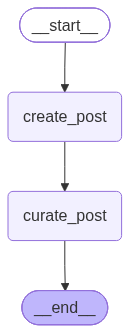

In [ ]:
from langgraph.graph import StateGraph,START,END

graph=StateGraph(graph_schema)
graph.add_node("create_post",create_post)
graph.add_node("curate_post",curate_post)

graph.add_edge(START,"create_post")
graph.add_edge("create_post","curate_post")
graph.add_edge("curate_post",END)

#compile the graph
pydantic_graph=graph.compile()

from IPython.display import Image,display
Image(pydantic_graph.get_graph().draw_mermaid_png())

In [ ]:
pydantic_graph.invoke(
    {
        "topic":"The importance of data privacy in the digital age",
        "post":"",
        "curated_post":""
    }
)

{'topic': 'The importance of data privacy in the digital age',
 'post': "**The Importance of Data Privacy in the Digital Age**\n\nAs we continue to navigate the vast and ever-evolving digital landscape, it's becoming increasingly clear that data privacy is no longer just a nicety, but a necessity. With the sheer amount of personal and sensitive information being shared online, it's imperative that we prioritize the protection of our data.\n\nIn today's digital age, our personal data is being collected, stored, and shared at an unprecedented rate. From social media platforms to online shopping, our every move is being tracked and analyzed. While this can bring many benefits, such as personalized experiences and targeted advertising, it also poses significant risks to our privacy and security.\n\n**The Consequences of Neglecting Data Privacy**\n\nIgnoring data privacy can have severe consequences, including:\n\n Identity theft and financial fraud\n Data breaches and cyber attacks\n Loss 